# 1.Cargar Librerias

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import configparser
import shutil
from glob import glob
import random
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import configparser
import random
from glob import glob



# 2. Configurar el dataset

In [ ]:
# Mount Google Drive
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
BASE = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/soccernet"
MOT_TRAIN_ROOT = os.path.join(BASE, "train")

YOLO_ROOT = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/yolo_soccer"

import os
for sub in ["images/train", "images/val", "labels/train", "labels/val"]:
    os.makedirs(os.path.join(YOLO_ROOT, sub), exist_ok=True)


## 2.1 Análisis exploratorio

In [3]:
#BASE = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/soccernet"
#MOT_TRAIN_ROOT = os.path.join(BASE, "train")

print("BASE:", BASE)
print("Existe BASE?:", os.path.exists(BASE))
print("MOT_TRAIN_ROOT:", MOT_TRAIN_ROOT)
print("Existe train?:", os.path.exists(MOT_TRAIN_ROOT))

seqs = sorted([d for d in os.listdir(MOT_TRAIN_ROOT) if os.path.isdir(os.path.join(MOT_TRAIN_ROOT, d))])
print("Número de secuencias (train):", len(seqs))
print("Ejemplos:", seqs[:5])


BASE: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/soccernet
Existe BASE?: True
MOT_TRAIN_ROOT: /content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/soccernet/train
Existe train?: True
Número de secuencias (train): 57
Ejemplos: ['SNMOT-060', 'SNMOT-061', 'SNMOT-062', 'SNMOT-063', 'SNMOT-064']


In [4]:
def inspect_sequence(seq_name):
    seq_dir = os.path.join(MOT_TRAIN_ROOT, seq_name)
    img_dir = os.path.join(seq_dir, "img1")
    gt_path = os.path.join(seq_dir, "gt", "gt.txt")
    seqinfo_path = os.path.join(seq_dir, "seqinfo.ini")
    gameinfo_path = os.path.join(seq_dir, "gameinfo.ini")

    print("\n===", seq_name, "===")
    print("img1 existe?:", os.path.exists(img_dir), "| #frames:", len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0)
    print("gt.txt existe?:", os.path.exists(gt_path))
    print("seqinfo.ini existe?:", os.path.exists(seqinfo_path))
    print("gameinfo.ini existe?:", os.path.exists(gameinfo_path))

inspect_sequence(seqs[0])



=== SNMOT-060 ===
img1 existe?: True | #frames: 750
gt.txt existe?: True
seqinfo.ini existe?: True
gameinfo.ini existe?: True


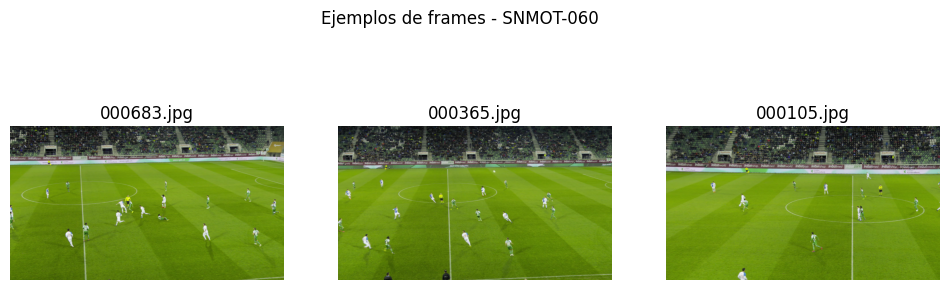

In [5]:
def show_random_frames(seq_name, n=3):
    seq_dir = os.path.join(MOT_TRAIN_ROOT, seq_name)
    img_dir = os.path.join(seq_dir, "img1")
    frames = sorted(glob(os.path.join(img_dir, "*.jpg")))
    if len(frames) == 0:
        print("No hay frames en", img_dir); return

    chosen = random.sample(frames, k=min(n, len(frames)))
    plt.figure(figsize=(12, 4))
    for i, fp in enumerate(chosen, 1):
        img = cv2.imread(fp)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, len(chosen), i)
        plt.imshow(img)
        plt.title(os.path.basename(fp))
        plt.axis("off")
    plt.suptitle(f"Ejemplos de frames - {seq_name}")
    plt.show()

show_random_frames(seqs[0], n=3)


In [6]:
def read_seqinfo(seq_name):
    seq_dir = os.path.join(MOT_TRAIN_ROOT, seq_name)
    seqinfo_path = os.path.join(seq_dir, "seqinfo.ini")
    cfg = configparser.ConfigParser()
    cfg.read(seqinfo_path)
    fps = int(cfg["Sequence"]["frameRate"])
    W = int(cfg["Sequence"]["imWidth"])
    H = int(cfg["Sequence"]["imHeight"])
    L = int(cfg["Sequence"].get("seqLength", 0))
    return fps, W, H, L

meta = []
for s in seqs[:10]:  # muestra rápido con 10 (puedes ampliar)
    try:
        fps, W, H, L = read_seqinfo(s)
        meta.append([s, fps, W, H, L])
    except Exception as e:
        print("Error leyendo seqinfo:", s, e)

df_meta = pd.DataFrame(meta, columns=["seq", "fps", "W", "H", "seqLength"])
df_meta


,seq,fps,W,H,seqLength
0,SNMOT-060,25,1920,1080,750
1,SNMOT-061,25,1920,1080,750
2,SNMOT-062,25,1920,1080,750
3,SNMOT-063,25,1920,1080,750
4,SNMOT-064,25,1920,1080,750
5,SNMOT-065,25,1920,1080,750
6,SNMOT-066,25,1920,1080,750
7,SNMOT-067,25,1920,1080,750
8,SNMOT-068,25,1920,1080,750
9,SNMOT-069,25,1920,1080,750


In [7]:
def get_tracklet_roles(gameinfo_path):
    cfg = configparser.ConfigParser()
    cfg.read(gameinfo_path)
    roles = {}
    for key, value in cfg["Sequence"].items():
        if not key.startswith("trackletid_"):
            continue
        tid = int(key.split("_")[1])
        role_team = value.split(";")[0].strip().lower()
        main_role = role_team.split()[0]  # player, goalkeeper, referee, ball
        roles[tid] = main_role
    return roles

def count_roles_in_sequence(seq_name):
    seq_dir = os.path.join(MOT_TRAIN_ROOT, seq_name)
    gt_path = os.path.join(seq_dir, "gt", "gt.txt")
    gameinfo_path = os.path.join(seq_dir, "gameinfo.ini")

    track_roles = get_tracklet_roles(gameinfo_path)

    df = pd.read_csv(
        gt_path, header=None,
        names=["frame","id","x","y","w","h","conf","x2","y2","z"]
    )
    df = df[df["conf"] > 0].copy()
    df["role"] = df["id"].map(track_roles)

    # Conteo por detección (cada bbox en cada frame)
    return df["role"].value_counts(dropna=False)

# conteo en pocas secuencias para explorar rápido
counts = {}
for s in seqs[:5]:
    counts[s] = count_roles_in_sequence(s)

df_counts = pd.DataFrame(counts).fillna(0).astype(int)
df_counts


,SNMOT-060,SNMOT-061,SNMOT-062,SNMOT-063,SNMOT-064
role,,,,,
ball,734,740,750,750,590
goalkeeper,163,344,138,75,0
goalkeepers,125,128,0,104,372
player,11079,9029,11437,10066,13872
referee,1439,948,1058,1228,1391


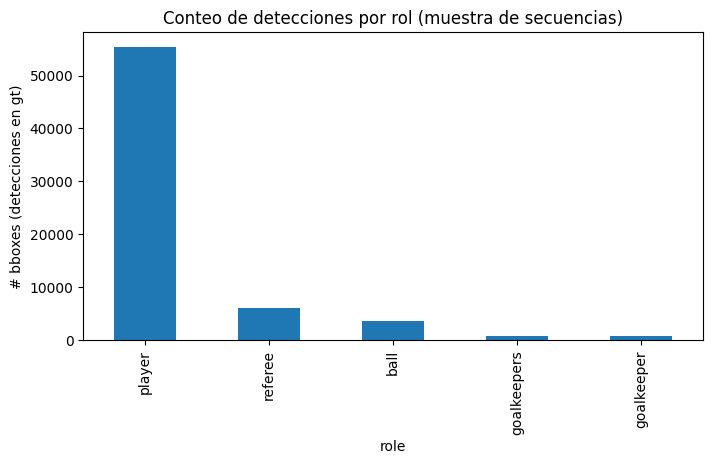

player+goalkeeper: 56203 | ball: 3564 | ratio (player/ball): 15.769640852974186


In [8]:
# Suma total en las secuencias muestreadas
total = df_counts.sum(axis=1).sort_values(ascending=False)
total.plot(kind="bar", figsize=(8,4))
plt.title("Conteo de detecciones por rol (muestra de secuencias)")
plt.ylabel("# bboxes (detecciones en gt)")
plt.show()

# Ratio player/ball (usando roles nativos)
player_like = total.get("player", 0) + total.get("goalkeeper", 0)
ball = total.get("ball", 0)
ratio = (player_like / ball) if ball > 0 else None
print("player+goalkeeper:", player_like, "| ball:", ball, "| ratio (player/ball):", ratio)


## 2.2 Dataset Formato YOLO

In [9]:

def get_tracklet_roles(gameinfo_path):
    """
    Lee gameinfo.ini y devuelve un dict:
    track_id (int) -> rol ('player', 'goalkeeper', 'referee', 'ball', etc.)
    """
    cfg = configparser.ConfigParser()
    cfg.read(gameinfo_path)

    roles = {}
    for key, value in cfg["Sequence"].items():
        if not key.startswith("trackletid_"):
            continue
        # key: 'trackletid_19' -> 19
        tid = int(key.split("_")[1])

        # value: 'player team left;24' o 'ball;1'
        parts = value.split(";")
        role_team = parts[0].strip().lower()   # 'player team left' o 'ball'
        # jersey = parts[1].strip()  # no lo usamos ahora

        # rol principal = primera palabra
        main_role = role_team.split()[0]  # 'player', 'goalkeeper', 'referee', 'ball'
        roles[tid] = main_role
    return roles


def process_sequence_to_yolo_with_ball(seq_name, train_ratio=0.8):
    seq_dir = os.path.join(MOT_TRAIN_ROOT, seq_name)
    img_dir = os.path.join(seq_dir, "img1")
    gt_path = os.path.join(seq_dir, "gt", "gt.txt")
    seqinfo_path = os.path.join(seq_dir, "seqinfo.ini")
    gameinfo_path = os.path.join(seq_dir, "gameinfo.ini")

    if not (os.path.exists(img_dir) and os.path.exists(gt_path)
            and os.path.exists(seqinfo_path) and os.path.exists(gameinfo_path)):
        print(f"Omitiendo {seq_name}: falta img1/ o gt/ o seqinfo.ini o gameinfo.ini")
        return

    # 1) tamaño de imagen
    config = configparser.ConfigParser()
    config.read(seqinfo_path)
    W = int(config["Sequence"]["imWidth"])
    H = int(config["Sequence"]["imHeight"])

    # 2) roles de tracklets
    track_roles = get_tracklet_roles(gameinfo_path)

    # 3) leer gt.txt (formato MOT)
    df = pd.read_csv(
        gt_path,
        header=None,
        names=["frame", "id", "x", "y", "w", "h", "conf", "x2", "y2", "z"],
    )
    df = df[df["conf"] > 0].copy()

    # filtramos solo tracklets conocidos en gameinfo
    df = df[df["id"].isin(track_roles.keys())]

    frames = sorted(df["frame"].unique().tolist())
    n_frames = len(frames)
    if n_frames == 0:
        print(f"{seq_name}: sin frames válidos en gt.txt")
        return

    n_train = int(train_ratio * n_frames)
    train_frames = set(frames[:n_train])
    val_frames = set(frames[n_train:])

    print(f"{seq_name}: {n_frames} frames -> {len(train_frames)} train, {len(val_frames)} val")

    for f in frames:
        img_name = f"{f:06d}.jpg"
        src_img_path = os.path.join(img_dir, img_name)
        if not os.path.exists(src_img_path):
            continue

        split = "train" if f in train_frames else "val"
        out_img_name = f"{seq_name}_{f:06d}.jpg"

        dst_img_path = os.path.join(YOLO_ROOT, "images", split, out_img_name)
        dst_label_path = os.path.join(YOLO_ROOT, "labels", split, out_img_name.replace(".jpg", ".txt"))

        shutil.copy2(src_img_path, dst_img_path)

        df_f = df[df["frame"] == f]

        yolo_lines = []
        for _, row in df_f.iterrows():
            tid = int(row["id"])
            role = track_roles.get(tid, None)
            if role is None:
                continue

            # Mapeo de roles a clases YOLO:
            # class 0 -> player (incluye 'player' y 'goalkeeper')
            # class 1 -> ball
            # 'referee' lo ignoramos (o podrías sumar otra clase si quisieras)
            if role == "ball":
                cid = 1
            elif role in ["player", "goalkeeper"]:
                cid = 0
            else:
                # por ejemplo 'referee' -> lo ignoramos
                continue

            x, y, w_box, h_box = row["x"], row["y"], row["w"], row["h"]

            x_center = (x + w_box / 2.0) / W
            y_center = (y + h_box / 2.0) / H
            ww = w_box / W
            hh = h_box / H

            yolo_lines.append(f"{cid} {x_center:.6f} {y_center:.6f} {ww:.6f} {hh:.6f}\n")

        if yolo_lines:
            with open(dst_label_path, "w") as f_out:
                f_out.writelines(yolo_lines)


In [10]:
seqs = sorted(os.listdir(MOT_TRAIN_ROOT))
for seq in seqs:
    process_sequence_to_yolo_with_ball(seq)


SNMOT-060: 750 frames -> 600 train, 150 val
SNMOT-061: 750 frames -> 600 train, 150 val
SNMOT-062: 750 frames -> 600 train, 150 val
SNMOT-063: 750 frames -> 600 train, 150 val
SNMOT-064: 750 frames -> 600 train, 150 val
SNMOT-065: 750 frames -> 600 train, 150 val
SNMOT-066: 750 frames -> 600 train, 150 val
SNMOT-067: 750 frames -> 600 train, 150 val
SNMOT-068: 750 frames -> 600 train, 150 val
SNMOT-069: 750 frames -> 600 train, 150 val
SNMOT-070: 750 frames -> 600 train, 150 val
SNMOT-071: 750 frames -> 600 train, 150 val
SNMOT-072: 750 frames -> 600 train, 150 val
SNMOT-073: 750 frames -> 600 train, 150 val
SNMOT-074: 750 frames -> 600 train, 150 val
SNMOT-075: 750 frames -> 600 train, 150 val
SNMOT-076: 750 frames -> 600 train, 150 val
SNMOT-077: 750 frames -> 600 train, 150 val
SNMOT-097: 750 frames -> 600 train, 150 val
SNMOT-098: 750 frames -> 600 train, 150 val
SNMOT-099: 750 frames -> 600 train, 150 val
SNMOT-100: 750 frames -> 600 train, 150 val
SNMOT-101: 750 frames -> 600 tra

KeyboardInterrupt: 

## 2.1 Visualizar un ejemplo

In [ ]:
YOLO_ROOT = "/content/drive/MyDrive/UNAL/Visión por computador/TareasDigiVision/sistema-de-deteccion/data/yolo_soccer"

def show_yolo_label(split="train"):
    img_dir = os.path.join(YOLO_ROOT, "images", split)
    label_dir = os.path.join(YOLO_ROOT, "labels", split)

    # escoger random
    img_list = os.listdir(img_dir)
    if len(img_list) == 0:
        print("No hay imágenes en", img_dir)
        return

    img_name = random.choice(img_list)
    img_path = os.path.join(img_dir, img_name)
    label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

    print("Mostrando:", img_name)

    # leer imagen
    img = cv2.imread(img_path)
    if img is None:
        print("Error leyendo imagen:", img_path)
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W, _ = img.shape

    # leer etiquetas
    if not os.path.exists(label_path):
        print("No existe archivo de etiqueta:", label_path)
        return

    with open(label_path, "r") as f:
        lines = f.readlines()

    for ln in lines:
        cid, xc, yc, bw, bh = ln.strip().split()
        cid = int(cid)
        xc, yc, bw, bh = map(float, (xc, yc, bw, bh))

        # convertir YOLO → píxeles
        x1 = int((xc - bw / 2) * W)
        y1 = int((yc - bh / 2) * H)
        x2 = int((xc + bw / 2) * W)
        y2 = int((yc + bh / 2) * H)

        # colores según clase
        if cid == 0:
            color = (0, 255, 0)   # player (verde)
            label = "player"
        else:
            color = (255, 0, 0)   # ball (rojo)
            label = "ball"

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"{split} → {img_name}")
    plt.axis("off")
    plt.show()


Mostrando: SNMOT-112_000236.jpg


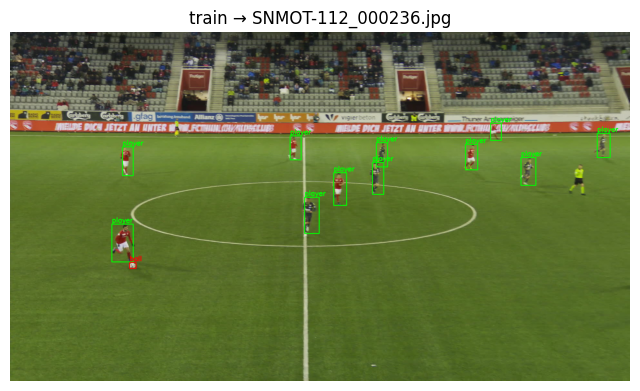

In [ ]:
show_yolo_label("train")


Mostrando: SNMOT-157_000623.jpg


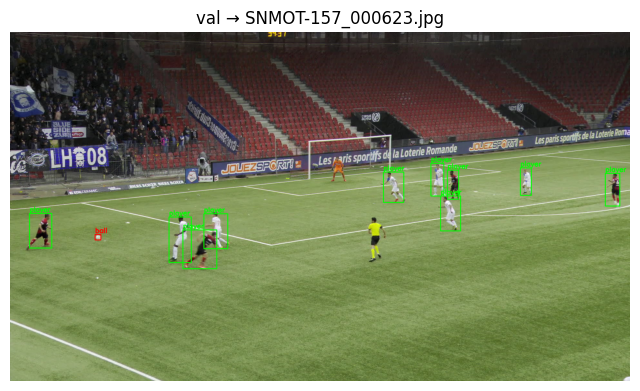

In [ ]:
show_yolo_label("val")
